<a href="https://colab.research.google.com/github/NielsRogge/Transformers-Tutorials/blob/master/HQ-SAM/Inference_with_HQ_SAM_for_fine_grained_mask_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Using HQ-SAM (High-Quality Segment Anything Model) to generate high-quality segmentation masks

| <img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/model_doc/sam-beancans.png" alt="Snow" width="300" height="300"> | <img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/model_doc/sam-dog-masks.png" alt="Forest" width="300" height="300"> | <img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/model_doc/sam-car-seg.png" alt="Mountains" width="300" height="300"> |
|---------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------|


This notebook demonstrates how to use the HQ-SAM (High-Quality Segment Anything Model) to segment objects in images.

The model is an upgrade of the [Segment Anything Model](https://ai.facebook.com/research/publications/segment-anything/) introduced by Meta in 2023. The original source code can be found [here](https://github.com/SysCV/sam-hq).

This notebook demonstrates how to use the `Transformers` library to leverage the different use cases of the model.

This is a direct adaptation of the [SAM notebook](https://github.com/huggingface/notebooks/blob/main/examples/segment_anything.ipynb) for HQ-SAM, which can serve as a drop-in replacement. Major kudos go to the original HF folks writing that notebook.

As stated by that notebook:
> Segment Anything Model (SAM), predicts object masks given prompts that indicate the desired object. The model first converts the image into an image embedding that allows high quality masks to be efficiently produced from a prompt.

HQ-SAM is the exact same thing, just with higher quality results!

* Docs: https://huggingface.co/docs/transformers/main/en/model_doc/sam_hq
* Model on the hub:https://huggingface.co/syscv-community.

We start by installing Transformers from source here since the HQ-SAM is brand new at the time of writing. It will be included in the next PyPi release.

In [1]:
!pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Utility functions

Below, a set of utility functions are defined which allow us to show segmentation masks, bounding  boxes and 2D points on images (as well as their combinations).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

def show_boxes_on_image(raw_image, boxes):
    plt.figure(figsize=(10,10))
    plt.imshow(raw_image)
    for box in boxes:
      show_box(box, plt.gca())
    plt.axis('on')
    plt.show()

def show_points_on_image(raw_image, input_points, input_labels=None):
    plt.figure(figsize=(10,10))
    plt.imshow(raw_image)
    input_points = np.array(input_points)
    if input_labels is None:
      labels = np.ones_like(input_points[:, 0])
    else:
      labels = np.array(input_labels)
    show_points(input_points, labels, plt.gca())
    plt.axis('on')
    plt.show()

def show_points_and_boxes_on_image(raw_image, boxes, input_points, input_labels=None):
    plt.figure(figsize=(10,10))
    plt.imshow(raw_image)
    input_points = np.array(input_points)
    if input_labels is None:
      labels = np.ones_like(input_points[:, 0])
    else:
      labels = np.array(input_labels)
    show_points(input_points, labels, plt.gca())
    for box in boxes:
      show_box(box, plt.gca())
    plt.axis('on')
    plt.show()


def show_points_and_boxes_on_image(raw_image, boxes, input_points, input_labels=None):
    plt.figure(figsize=(10,10))
    plt.imshow(raw_image)
    input_points = np.array(input_points)
    if input_labels is None:
      labels = np.ones_like(input_points[:, 0])
    else:
      labels = np.array(input_labels)
    show_points(input_points, labels, plt.gca())
    for box in boxes:
      show_box(box, plt.gca())
    plt.axis('on')
    plt.show()


def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_masks_on_image(raw_image, masks, scores):
    if len(masks.shape) == 4:
      masks = masks.squeeze()
    if scores.shape[0] == 1:
      scores = scores.squeeze()

    nb_predictions = scores.shape[-1]
    fig, axes = plt.subplots(1, nb_predictions, figsize=(15, 15))

    for i, (mask, score) in enumerate(zip(masks, scores)):
      mask = mask.cpu().detach()
      axes[i].imshow(np.array(raw_image))
      show_mask(mask, axes[i])
      axes[i].title.set_text(f"Mask {i+1}, Score: {score.item():.3f}")
      axes[i].axis("off")
    plt.show()

## Load model

Next, it's time to load one of the pre-trained SAM-HQ models from the [hub](https://huggingface.co/syscv-community).

For the sake of this demonstration, we will use the `vit-base` checkpoint. Note that HQ-SAM also comes in large and huge versions (which result in even better results at the cost of heavier computation).

We also put the model on a GPU (make sure to set the "Runtime" to "GPU" in
case you're running this on Google Colab - we use a T4 GPU).

In [3]:
import torch
from transformers import SamHQModel, SamHQProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SamHQModel.from_pretrained("syscv-community/sam-hq-vit-base").to(device)
processor = SamHQProcessor.from_pretrained("syscv-community/sam-hq-vit-base")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/379M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/576 [00:00<?, ?B/s]

## Run predictions

Let's deeply dive into how you can run different type of predictions, given different inputs. You will see how to

- Generate segmentation masks given a 2D localization point
- Generate segmentation masks per given localization (one prediction per 2D point)
- Generate segmentation masks given a bounding box
- Generate segmentation masks given a bounding box and a 2D points
- Generate multiple segmentatation masks per image

### Load the example image

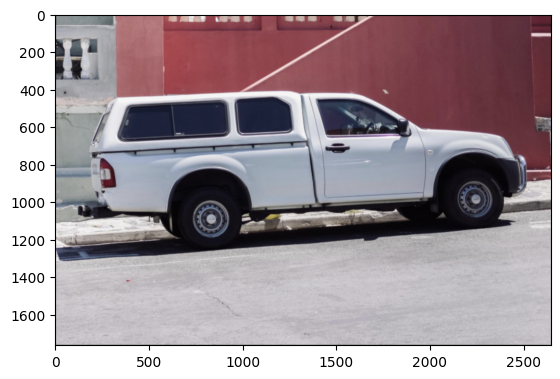

In [4]:
from PIL import Image
import requests

img_url = "https://huggingface.co/ybelkada/segment-anything/resolve/main/assets/car.png"
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")

plt.imshow(raw_image)

## Step 1: Retrieve the image embeddings

In order to avoid computing multiple times the same image embeddings, we will compute it only once, and use these embeddings to directly feed them to the model for faster inference.

Interestingly, compared to SAM, HQ-SAM also computes intermediate embeddings which can be reused.

In [5]:
inputs = processor(raw_image, return_tensors="pt").to(device)
image_embeddings, intermediate_embeddings = model.get_image_embeddings(inputs["pixel_values"])

/usr/local/lib/python3.11/dist-packages/transformers/image_processing_utils.py:44: UserWarning: The following named arguments are not valid for `SamImageProcessor.preprocess` and were ignored: 'point_pad_value'
  return self.preprocess(images, **kwargs)


## Usecase 1: Feed a set of 2D points to predict a mask

Let's first focus on the first classic use case of SAM.

SAM is a so-called "prompted" segmentation model, meaning it always requires a certain prompt or conditioning to generate segmentation masks. The prompts can be 2D points or bounding boxes for objects you care about.

Here we start by prompting the model with a single 2D point for which it needs to predict a segmentation mask. Note that you can also feed multiple 2D points at once: the more 2D points you provide, the better the resulting mask will be.

In this example, let's try to predict the mask that corresponds to the top left window of the parked car.

The input points need to be in the format:

`number_of_images, number_of_predictions, number_of_points_per_mask, 2`

With SAM you can either predict a single prediction given multiple points, or a prediction per point. This is denoted by the `num_predictions` dimension. We will see in the next sections how to perform this type of prediction.

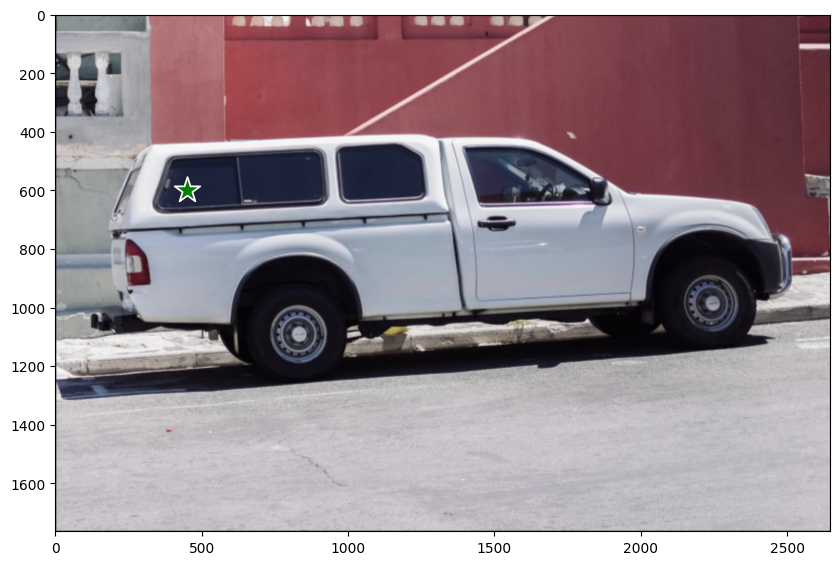

In [6]:
input_points = [[[450, 600]]]
show_points_on_image(raw_image, input_points[0])

For that, simply pass the raw image and the point to the processor. We then pass the prepared point along with the pre-computed image and intermediate embeddings to the model.

Passing the pre-computed image and intermediate embeddings makes it skip the heavy vision encoder.




In [7]:
inputs = processor(raw_image, input_points=input_points, return_tensors="pt").to(device)
# pop the pixel_values as they are not needed
inputs.pop("pixel_values", None)
inputs.update({"image_embeddings": image_embeddings})
inputs.update({"intermediate_embeddings": intermediate_embeddings})

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu())
scores = outputs.iou_scores

<ipython-input-2-5a1b8755e15a>:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


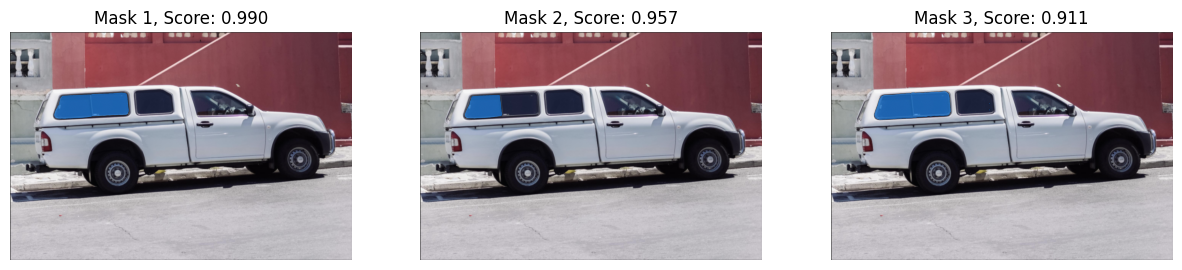

In [8]:
show_masks_on_image(raw_image, masks[0], scores)

As you can see, the predicted masks are sorted in their IoU score order. The first mask indeed seems to correspond to the mask of the top right window of the parked car.

You can also feed a set of points to predict a single mask. Let's try to predict a mask, given two points:

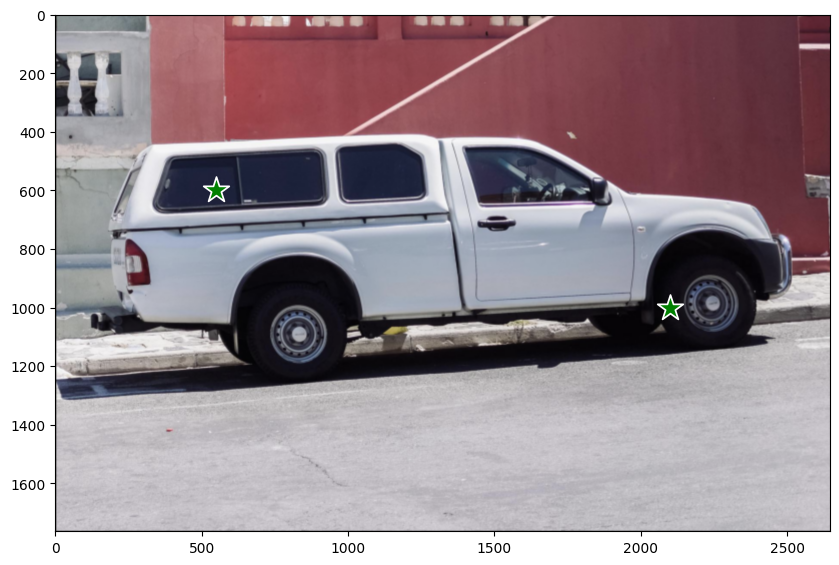

In [38]:
input_points = [[[550, 600], [2100, 1000]]]
show_points_on_image(raw_image, input_points)

In [10]:
inputs = processor(raw_image, input_points=input_points, return_tensors="pt").to(device)
# pop the pixel_values as they are not needed
inputs.pop("pixel_values", None)
inputs.update({"image_embeddings": image_embeddings})
inputs.update({"intermediate_embeddings": intermediate_embeddings})

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu())
scores = outputs.iou_scores

<ipython-input-2-5a1b8755e15a>:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


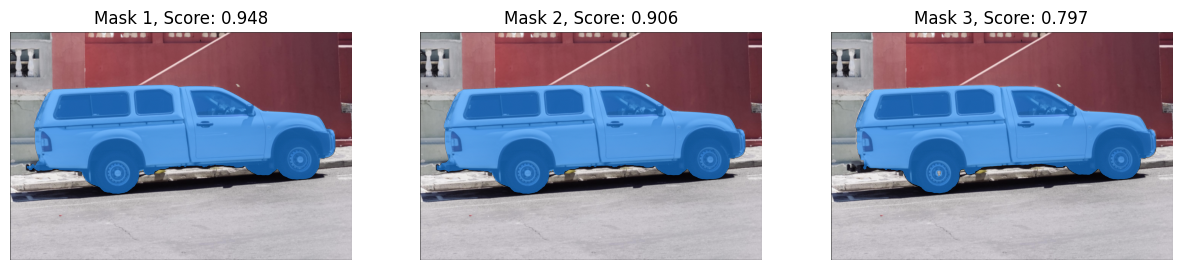

In [11]:
show_masks_on_image(raw_image, masks[0], scores)

In this case it seems to create a segmentation mask for the entire car. Great!

## Use case 2: Predict segmentations masks using bounding boxes

Another way to prompt the SAM model is with bounding boxes instead of 2 points.

Each bounding box needs to be a list of points, corresponding to the flattened coordinates of the top left point, and bottom right point of the bounding box. Let's look at an example below:

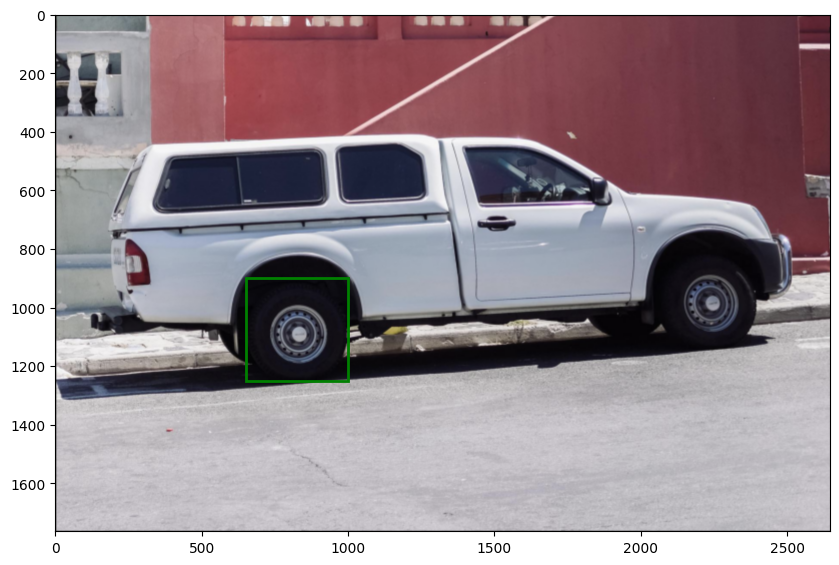

In [12]:
input_boxes = [[[650, 900, 1000, 1250]]]

show_boxes_on_image(raw_image, input_boxes[0])

We will try to segment the wheel that is present inside the bounding box! For that just run the following snippet

In [17]:
inputs = processor(raw_image, input_boxes=[input_boxes], return_tensors="pt").to(device)
inputs["input_boxes"].shape

/usr/local/lib/python3.11/dist-packages/transformers/image_processing_utils.py:44: UserWarning: The following named arguments are not valid for `SamImageProcessor.preprocess` and were ignored: 'point_pad_value'
  return self.preprocess(images, **kwargs)


torch.Size([1, 1, 4])

Next we can perform a forward pass on the HQ-SAM model (again skipping the heavy vision encoder by passing the already computed image and intermediate embeddings):

In [20]:
inputs.pop("pixel_values", None)
inputs.update({"image_embeddings": image_embeddings})
inputs.update({"intermediate_embeddings": intermediate_embeddings})

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu())
scores = outputs.iou_scores

<ipython-input-2-5a1b8755e15a>:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


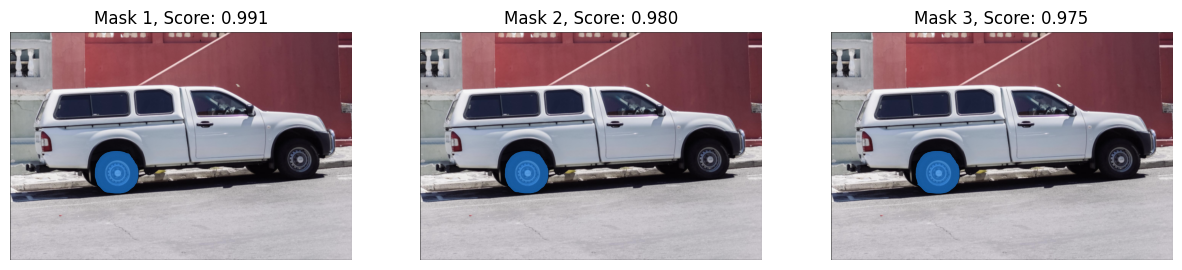

In [19]:
show_masks_on_image(raw_image, masks[0], scores)

It is possible to feed multiple boxes, however, this will lead to having one prediction per bounding box. i.e., you cannot combine multiple bounding boxes to get a single prediction. However, you can combine points and bounding boxes to get a prediction, and we will cover that in the next section.

## Use case 3: Predict segmentation masks given points and bounding boxes

We can combine the 2 ways of prompting! If you give the SAM model both 2D points and bounding boxes, it can generate a segmentation mask for it.

In [ ]:
input_boxes = [[[650, 900, 1000, 1250]]]
input_points = [[[820, 1080]]]

show_points_and_boxes_on_image(raw_image, input_boxes[0], input_points[0])

In [21]:
inputs = processor(raw_image, input_boxes=[input_boxes], input_points=[input_points], return_tensors="pt").to(device)

inputs.pop("pixel_values", None)
inputs.update({"image_embeddings": image_embeddings})
inputs.update({"intermediate_embeddings": intermediate_embeddings})

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu())
scores = outputs.iou_scores

/usr/local/lib/python3.11/dist-packages/transformers/image_processing_utils.py:44: UserWarning: The following named arguments are not valid for `SamImageProcessor.preprocess` and were ignored: 'point_pad_value'
  return self.preprocess(images, **kwargs)


<ipython-input-2-5a1b8755e15a>:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


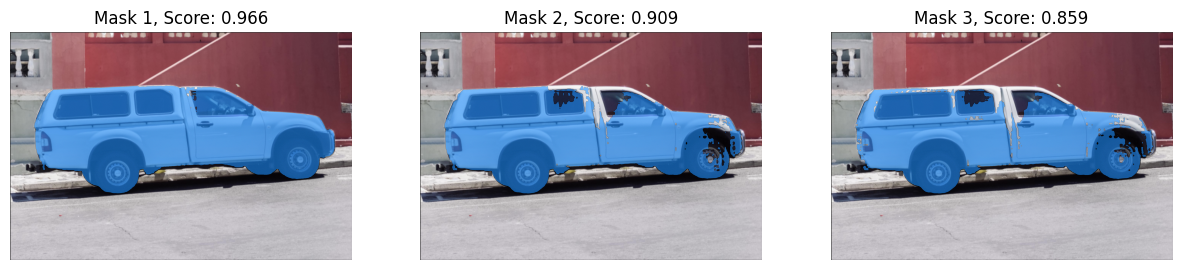

In [22]:
show_masks_on_image(raw_image, masks[0][0], scores[:, 0, :])

You can also pass points with a label to segment out that region. Let us have a deeper look below:

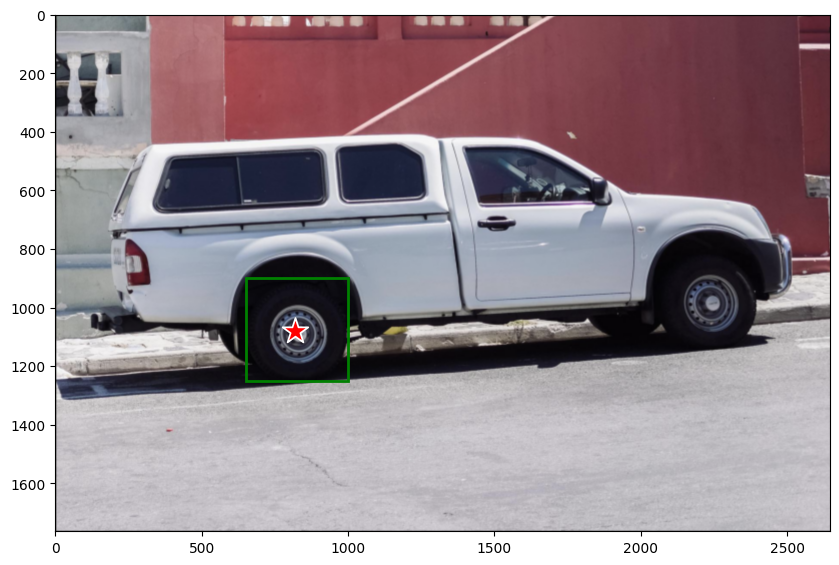

In [23]:
input_boxes = [[[650, 900, 1000, 1250]]]
input_points = [[[820, 1080]]]
labels = [0]

show_points_and_boxes_on_image(raw_image, input_boxes[0], input_points[0], labels)

In [24]:
input_boxes = [[[620, 900, 1000, 1255]]]
input_points = [[[820, 1080]]]
labels = [[0]]
inputs = processor(raw_image, input_boxes=[input_boxes], input_points=[input_points], input_labels=[labels], return_tensors="pt").to(device)

inputs.pop("pixel_values", None)
inputs.update({"image_embeddings": image_embeddings})
inputs.update({"intermediate_embeddings": intermediate_embeddings})

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu())
scores = outputs.iou_scores

<ipython-input-2-5a1b8755e15a>:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


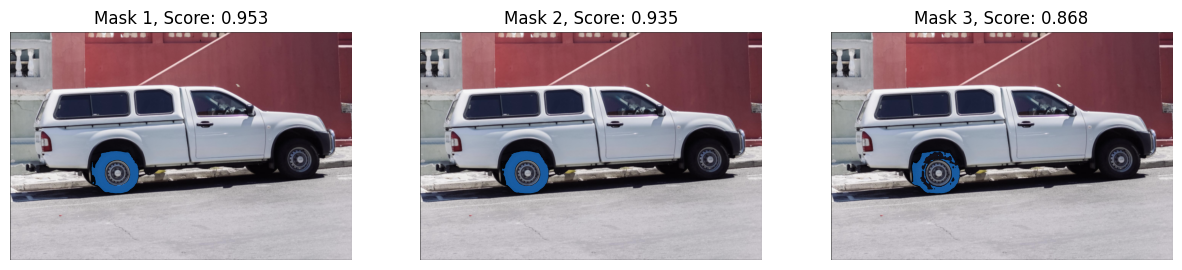

In [25]:
show_masks_on_image(raw_image, masks[0][0], scores[:, 0, :])

As you can see, the model managed to "ignore" the component that was specified by the point with the label `0`.

## Use case 4: Predict multiple masks per image

With SAM, you can also predict multiple masks per image. You can achieve that in two possible scenarios

- Feed multiple points in the `number_of_predictions` dimension
- Feed multiple bounding boxes to the same image

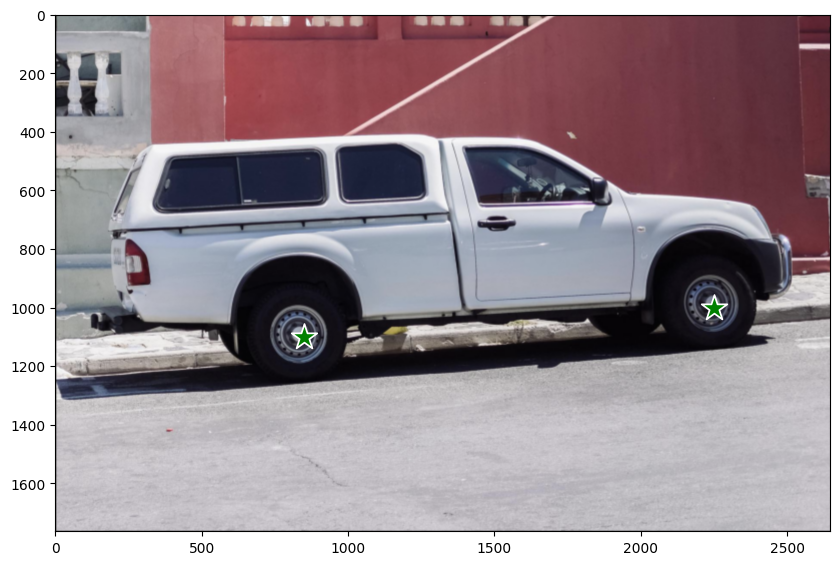

In [26]:
input_points = [[[850, 1100], [2250, 1000]]]
show_points_on_image(raw_image, input_points)

### Sub-use case 1: one prediction per point

To benefit from what we have described in the first bullet point, just change the input array to:

In [27]:
input_points = [[[850, 1100]], [[2250, 1000]]]

In order to add the desired dimension, and pass it to the `Processor`:

In [28]:
input_points = [[[[850, 1100]], [[2250, 1000]]]]
inputs = processor(raw_image, input_points=input_points, return_tensors="pt").to(device)
inputs["input_points"].shape

torch.Size([1, 2, 1, 2])

In [29]:
inputs.pop("pixel_values", None)
inputs.update({"image_embeddings": image_embeddings})
inputs.update({"intermediate_embeddings": intermediate_embeddings})

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu())
scores = outputs.iou_scores

Let's print the shapes of the output to understand better what is going on

In [30]:
scores.shape

torch.Size([1, 2, 3])

Here the first dimension corresponds to the image batch size, the second dimension corresponds to the `number_of_predictions` dimension. And the last dimension is the number of predicted masks **per prediction** , and it is set to 3 by default according to the official implementation.

<ipython-input-2-5a1b8755e15a>:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


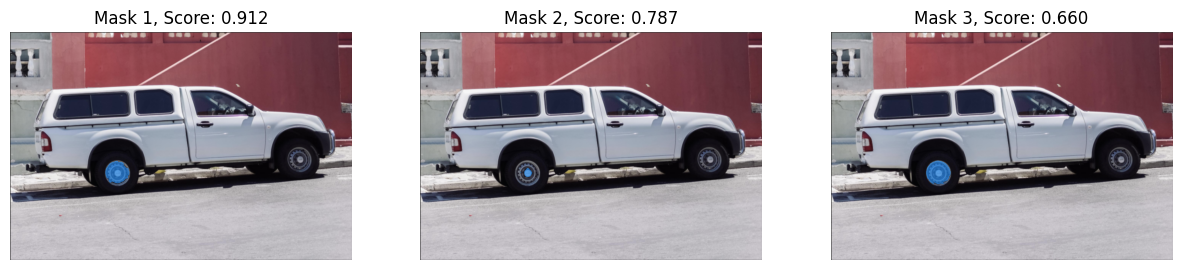

In [31]:
show_masks_on_image(raw_image, masks[0][0], scores[:, 0, :])

<ipython-input-2-5a1b8755e15a>:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


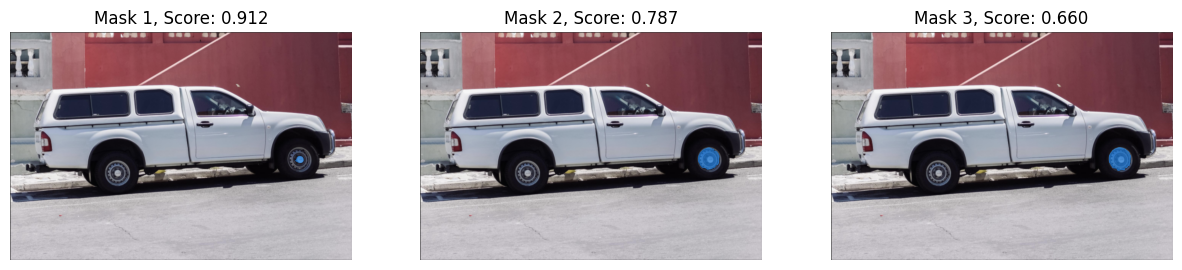

In [32]:
show_masks_on_image(raw_image, masks[0][1], scores[:, 0, :])

### Sub-use case 2: Feed multiple bounding boxes to the same image

You can also feed multiple bounding boxes to the same image and get one prediction per bounding box.

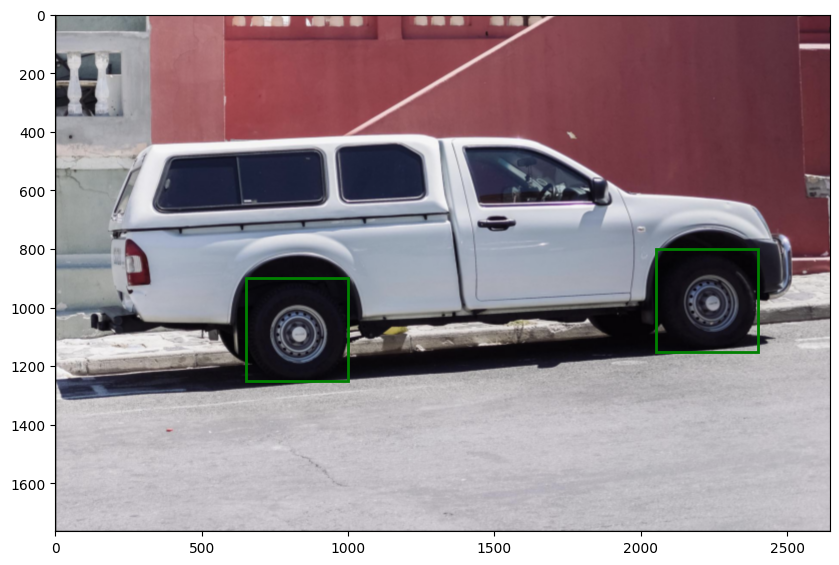

In [33]:
input_boxes = [[[650, 900, 1000, 1250], [2050, 800, 2400, 1150]]]

show_boxes_on_image(raw_image, input_boxes[0])

Just pass the input boxes as follows, to match the convention of the processor

In [34]:
input_boxes = [[[650, 900, 1000, 1250], [2050, 800, 2400, 1150]]]
inputs = processor(raw_image, input_boxes=input_boxes, return_tensors="pt").to(device)
inputs["input_boxes"].shape

torch.Size([1, 2, 4])

This time, let's just output a single mask per box, for that we can just pass `multimask_output=False` in the forward pass

In [35]:
inputs.pop("pixel_values", None)
inputs.update({"image_embeddings": image_embeddings})
inputs.update({"intermediate_embeddings": intermediate_embeddings})

with torch.no_grad():
    outputs = model(**inputs, multimask_output=False)

masks = processor.image_processor.post_process_masks(outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu())
scores = outputs.iou_scores

In [36]:
scores.shape

torch.Size([1, 2, 1])

As you can see, here we have predicted 2 masks in total! Let's check them now.

<ipython-input-2-5a1b8755e15a>:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


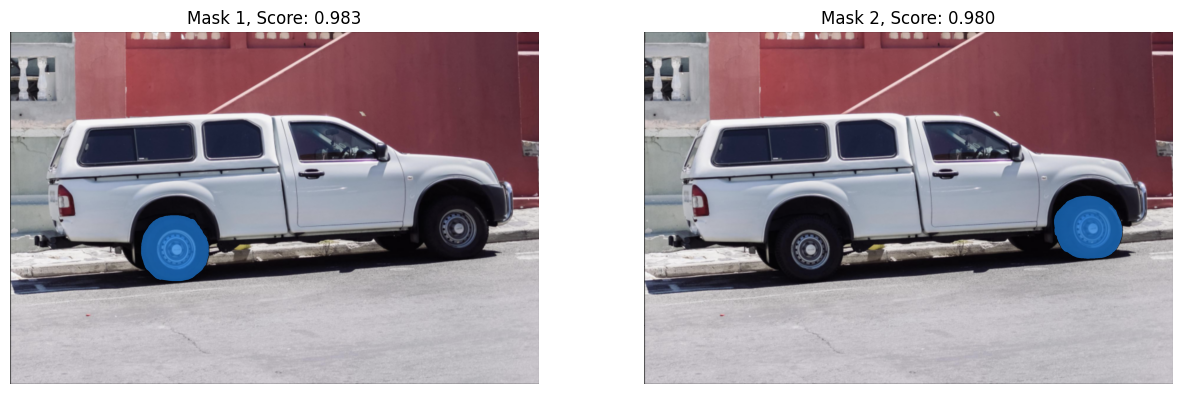

In [37]:
show_masks_on_image(raw_image, masks[0], scores)